In [8]:
pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ritwikb3/heart-disease-cleveland")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-cleveland' dataset.
Path to dataset files: /kaggle/input/heart-disease-cleveland


In [10]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [11]:
print("Downloaded Folder:", path)

for root, dirs, files in os.walk(path):
    for file in files:
        print(file)

Downloaded Folder: /kaggle/input/heart-disease-cleveland
Heart_disease_cleveland_new.csv


In [12]:
df = pd.read_csv(os.path.join(path, "Heart_disease_cleveland_new.csv"))

In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [14]:
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [35]:
X = df.drop("target", axis=1)
y = df["target"]

feature_names = X.columns.tolist()

In [36]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

In [16]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [17]:
imputer = SimpleImputer(strategy="median")

X = imputer.fit_transform(X)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    accuracy = accuracy_score(y_test, prediction)
    results.append([name, accuracy])

results_df = pd.DataFrame(results, columns=["Algorithm", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Algorithm,Accuracy
1,K-Nearest Neighbors,0.901639
4,Random Forest,0.885246
0,Logistic Regression,0.868852
5,Naive Bayes,0.868852
2,Support Vector Machine,0.852459
3,Decision Tree,0.721311


In [21]:
parameters = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,15,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print(grid.best_params_)

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [27]:
from sklearn.metrics import accuracy_score

# Update Random Forest result with tuned model
rf_pred = best_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

results_df.loc[
    results_df["Algorithm"] == "Random Forest",
    "Accuracy"
] = rf_accuracy

results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Algorithm,Accuracy
1,K-Nearest Neighbors,0.901639
4,Random Forest,0.901639
0,Logistic Regression,0.868852
5,Naive Bayes,0.868852
2,Support Vector Machine,0.852459
3,Decision Tree,0.721311


In [22]:
y_pred = best_model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy * 100)

Accuracy = 90.1639344262295


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



In [30]:
import os

os.makedirs("images", exist_ok=True)

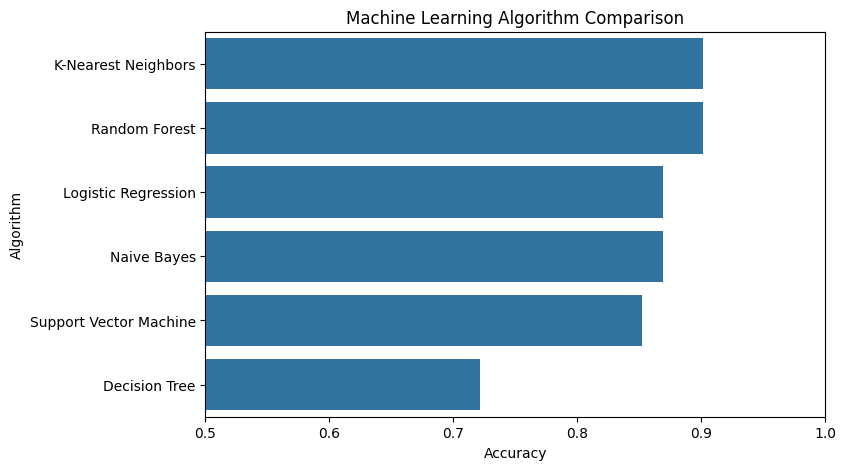

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Accuracy",
    y="Algorithm",
    data=results_df
)

plt.title("Machine Learning Algorithm Comparison")
plt.xlim(0.5,1.0)

plt.savefig("images/algorithm_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

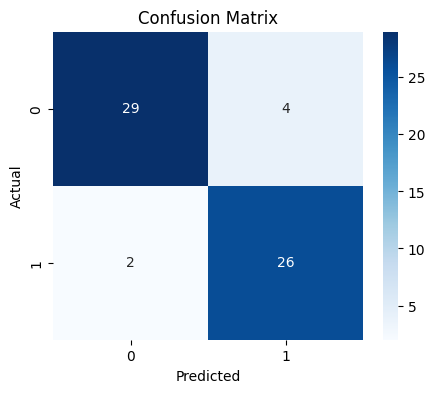

In [32]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

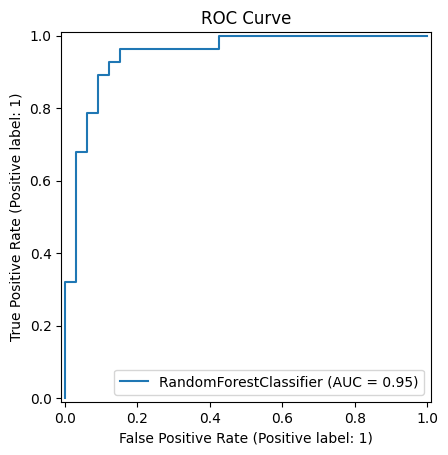

In [33]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve")

plt.savefig("images/roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

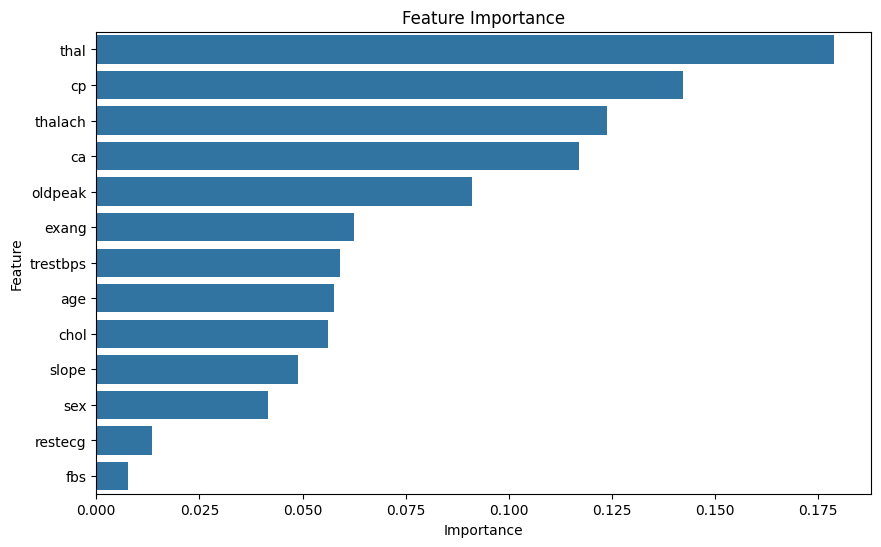

In [37]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Feature Importance")

plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

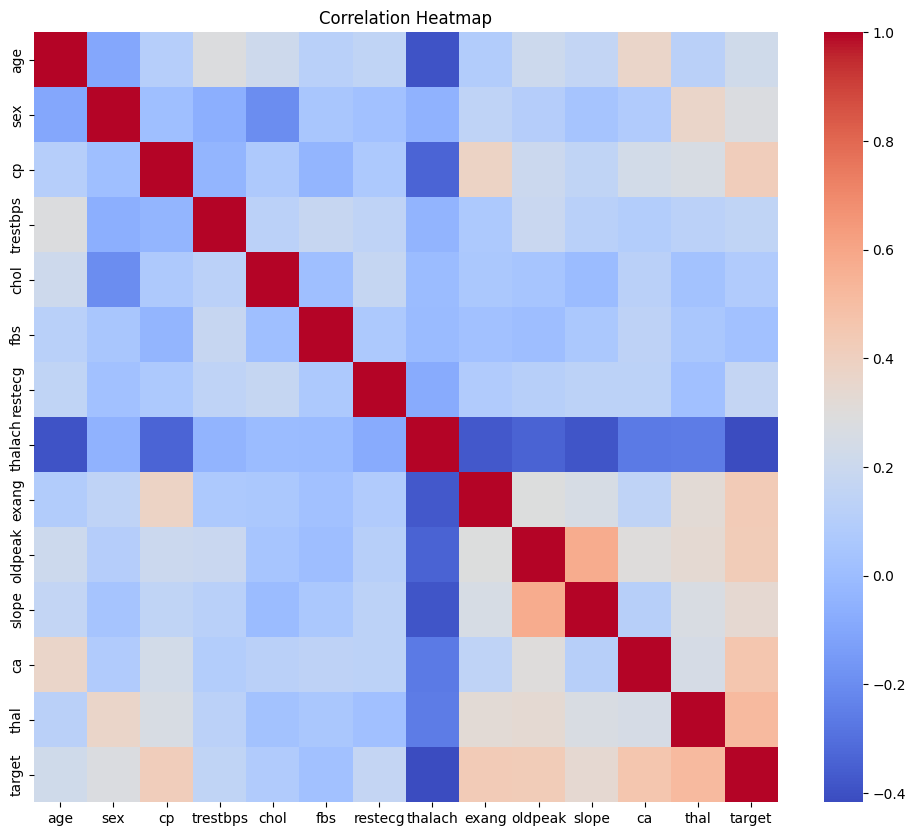

In [38]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(), cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [39]:
import os

print(os.listdir("images"))

['correlation_heatmap.png', 'confusion_matrix.png', 'roc_curve.png', 'feature_importance.png', 'algorithm_comparison.png']


In [40]:
from google.colab import files

files.download("images/algorithm_comparison.png")
files.download("images/confusion_matrix.png")
files.download("images/roc_curve.png")
files.download("images/feature_importance.png")
files.download("images/correlation_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>